# Questão 5

Agora a compressão é feita por blocos, usando DCT2 em janelas de 8x8 e 16x16,
para comparar a abordagem local com a compressão global da questão anterior.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy.fft import dct, idct, fft, ifft, dctn, idctn
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'sosias.jpg').exists():
    PRACTICE_DIR = CWD
elif (CWD / 'pratica_4' / 'sosias.jpg').exists():
    PRACTICE_DIR = (CWD / 'pratica_4').resolve()
else:
    PRACTICE_DIR = CWD

DATA_DIR = (PRACTICE_DIR.parent / 'data').resolve()
AUDIO_PATH = DATA_DIR / 'handel.wav'
IMAGE_PATH = (PRACTICE_DIR / 'sosias.jpg').resolve()


In [2]:
def to_float_mono(signal):
    signal = np.asarray(signal)
    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    return signal


def show_audio(signal, fs, label):
    signal = np.asarray(signal, dtype=np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    display(Audio(signal, rate=fs))
    print(label)


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def select_by_energy(coeffs, keep_energy):
    coeffs = np.asarray(coeffs)
    energy = np.abs(coeffs) ** 2
    flat_energy = energy.ravel()
    order = np.argsort(flat_energy)[::-1]
    cumulative = np.cumsum(flat_energy[order])
    total_energy = cumulative[-1]
    threshold = keep_energy * total_energy
    keep_count = int(np.searchsorted(cumulative, threshold, side='left')) + 1

    mask = np.zeros(coeffs.size, dtype=bool)
    mask[order[:keep_count]] = True
    mask = mask.reshape(coeffs.shape)

    compressed = np.zeros_like(coeffs)
    compressed[mask] = coeffs[mask]
    retained = float(np.sum(np.abs(compressed) ** 2) / total_energy)
    return compressed, keep_count, retained, mask


def compress_audio_dct(signal, keep_energy):
    coeffs = dct(signal, norm='ortho')
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = idct(compressed, norm='ortho')
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def compress_audio_fft(signal, keep_energy):
    coeffs = fft(signal)
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = np.real(ifft(compressed))
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def plot_time_and_error(original, reconstructed, fs, title):
    t = np.arange(len(original)) / fs
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(t, original, label='Original', alpha=0.8)
    axes[0].plot(t, reconstructed, label='Reconstruido', alpha=0.7)
    axes[0].set_title(title)
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()

    axes[1].plot(t, original - reconstructed, color='tab:red')
    axes[1].set_title('Erro de reconstrução')
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_ylabel('Erro')
    plt.tight_layout()
    plt.show()
def load_gray_image(path):
    image = Image.open(path).convert('L')
    array = np.asarray(image, dtype=np.float64) / 255.0
    return image, array


def compress_image_dct(image_array, keep_energy):
    coeffs = dctn(image_array, norm='ortho')
    compressed, keep_count, retained, mask = select_by_energy(coeffs, keep_energy)
    reconstructed = idctn(compressed, norm='ortho')
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
        'mask': mask,
    }


def blockwise_dct_compression(image_array, block_size, keep_energy):
    h, w = image_array.shape
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    padded = np.pad(image_array, ((0, pad_h), (0, pad_w)), mode='edge')
    reconstructed = np.zeros_like(padded)
    total_kept = 0
    total_coeffs = padded.size

    for i in range(0, padded.shape[0], block_size):
        for j in range(0, padded.shape[1], block_size):
            block = padded[i:i + block_size, j:j + block_size]
            coeffs = dctn(block, norm='ortho')
            compressed, keep_count, _, _ = select_by_energy(coeffs, keep_energy)
            reconstructed[i:i + block_size, j:j + block_size] = idctn(compressed, norm='ortho')
            total_kept += keep_count

    reconstructed = reconstructed[:h, :w]
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return {
        'reconstructed': reconstructed,
        'keep_count': total_kept,
        'compression_ratio': total_kept / total_coeffs,
    }


In [3]:
_, image = load_gray_image(IMAGE_PATH)
keep_levels = [0.995, 0.99, 0.90, 0.75, 0.50]

rows = []
reconstructions = {}

for block_size in [8, 16]:
    reconstructions[block_size] = {}
    for keep in keep_levels:
        result = blockwise_dct_compression(image, block_size=block_size, keep_energy=keep)
        key = f'{keep * 100:.1f}%'
        reconstructions[block_size][key] = result
        rows.append(
            {
                'Bloco': f'{block_size}x{block_size}',
                'Energia preservada': key,
                'Coeficientes mantidos': result['keep_count'],
                'Percentual de coeficientes': 100 * result['compression_ratio'],
                'MSE': mse(image, result['reconstructed']),
            }
        )

display_rows(rows, float_digits=8)


Bloco | Energia preservada | Coeficientes mantidos | Percentual de coeficientes | MSE       
------+--------------------+-----------------------+----------------------------+-----------
8x8   | 99.5%              | 49662                 | 6.15848214                 | 0.00033235
8x8   | 99.0%              | 38857                 | 4.81857639                 | 0.00059645
8x8   | 90.0%              | 16023                 | 1.98697917                 | 0.00304056
8x8   | 75.0%              | 13331                 | 1.65314980                 | 0.00495812
8x8   | 50.0%              | 12643                 | 1.56783234                 | 0.00630627
16x16 | 99.5%              | 43629                 | 5.41034226                 | 0.00053907
16x16 | 99.0%              | 28915                 | 3.58568948                 | 0.00099922
16x16 | 90.0%              | 5599                  | 0.69432044                 | 0.00533653
16x16 | 75.0%              | 3596                  | 0.44593254       

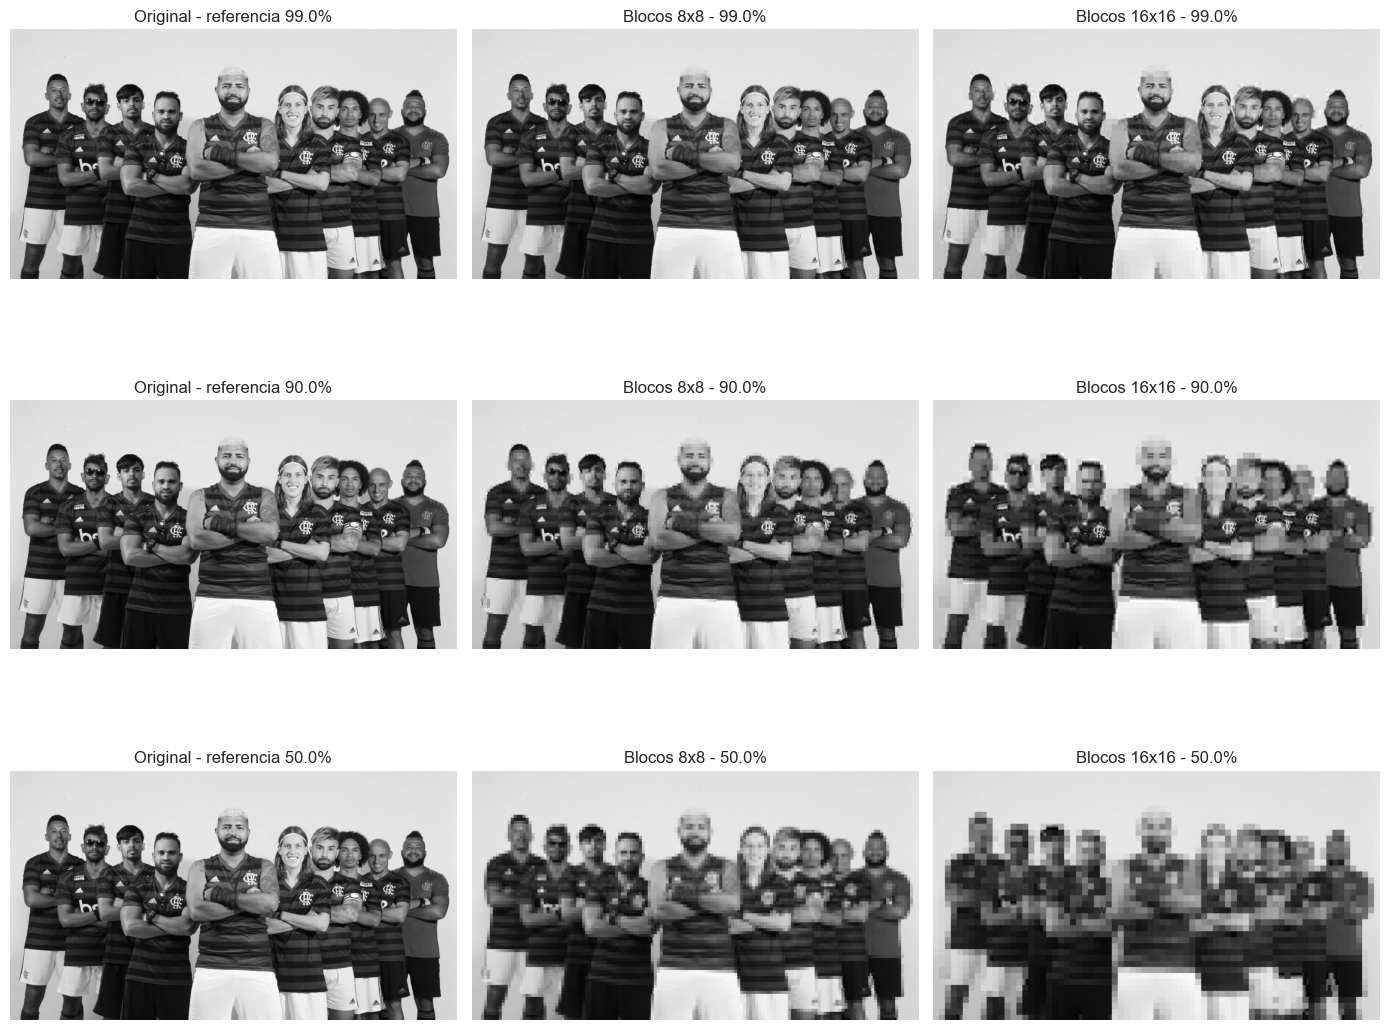

In [4]:
selected_levels = ['99.0%', '90.0%', '50.0%']
fig, axes = plt.subplots(len(selected_levels), 3, figsize=(14, 4 * len(selected_levels)))

for row_idx, level in enumerate(selected_levels):
    axes[row_idx, 0].imshow(image, cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 0].set_title(f'Original - referencia {level}')
    axes[row_idx, 0].axis('off')

    for col_idx, block_size in enumerate([8, 16], start=1):
        reconstructed = reconstructions[block_size][level]['reconstructed']
        axes[row_idx, col_idx].imshow(reconstructed, cmap='gray', vmin=0, vmax=1)
        axes[row_idx, col_idx].set_title(f'Blocos {block_size}x{block_size} - {level}')
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()


## Comentários

- Blocos 8x8 costumam controlar melhor a variação local da imagem e se aproximam mais do padrão usado em codecs práticos, como JPEG.
- Blocos 16x16 podem manter mais estrutura global por bloco, mas também podem introduzir artefatos maiores quando a compressão é agressiva.
- Em comparação com a DCT global, a abordagem por blocos é mais adequada para implementação prática e processamento local, embora possa gerar bloqueamento visível.
